<a href="https://colab.research.google.com/github/Adrian-HI-LO/Adrian-HI-LO/blob/main/Bussines_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install sagemaker==2.215.0 boto3 --force-reinstall

  Using cached sagemaker-2.215.0-py3-none-any.whl.metadata (14 kB)
  Using cached boto3-1.42.72-py3-none-any.whl.metadata (6.7 kB)
  Using cached attrs-23.2.0-py3-none-any.whl.metadata (9.5 kB)
  Using cached cloudpickle-2.2.1-py3-none-any.whl.metadata (6.9 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached protobuf-4.25.8-cp37-abi3-manylinux2014_x86_64.whl.metadata (541 bytes)
  Using cached smdebug_rulesconfig-1.0.1-py2.py3-none-any.whl.metadata (943 bytes)
  Using cached importlib_metadata-6.11.0-py3-none-any.whl.metadata (4.9 kB)
  Using cached packaging-26.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached pandas-3.0.1-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached pathos-0.3.5-py3-none-any.whl.metadata (11 kB)
  Using cached schema-0.7.8-py2.py3-none-any.whl.metadata (34 kB)
  Using cached pyy

In [ ]:
!pip install xgboost==1.5.1

In [ ]:
!pip install pandas numpy matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import userdata
aws_access_key_id = userdata.get('AWS_ACCESS_KEY_ID')
aws_secret_access_key = userdata.get('AWS_SECRET_ACCESS_KEY')
aws_region = 'us-east-1'

In [ ]:
import sagemaker
import boto3

boto_session = boto3.Session(
    aws_access_key_id=aws_access_key_id,
    aws_secret_access_key=aws_secret_access_key,
    region_name=aws_region
)

# Con la versión 2.x, este atributo sí debería estar disponible
sagemaker_session = sagemaker.Session(boto_session=boto_session)
bucket = sagemaker_session.default_bucket()

print(f"Sesión iniciada correctamente. Usando el bucket S3: {bucket}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /root/.config/sagemaker/config.yaml
Sesión iniciada correctamente. Usando el bucket S3: sagemaker-us-east-1-231351515337


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# creditcard_df = pd.read_csv('./DataSet/UCI_Credit_Card.csv')
creditcard_df = pd.read_csv('/content/drive/MyDrive/DS_Bussines/UCI_Credit_Card.csv')


In [ ]:
creditcard_df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,3,1,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [ ]:
creditcard_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   30000 non-null

In [ ]:
creditcard_df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


<Axes: >

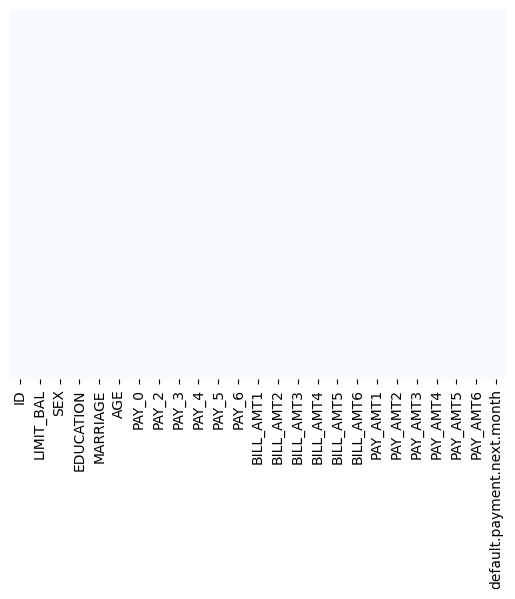

In [ ]:
sns.heatmap(creditcard_df.isnull(), yticklabels=False,cbar=False,cmap='Blues')

array([[<Axes: title={'center': 'ID'}>,
        <Axes: title={'center': 'LIMIT_BAL'}>,
        <Axes: title={'center': 'SEX'}>,
        <Axes: title={'center': 'EDUCATION'}>,
        <Axes: title={'center': 'MARRIAGE'}>],
       [<Axes: title={'center': 'AGE'}>,
        <Axes: title={'center': 'PAY_0'}>,
        <Axes: title={'center': 'PAY_2'}>,
        <Axes: title={'center': 'PAY_3'}>,
        <Axes: title={'center': 'PAY_4'}>],
       [<Axes: title={'center': 'PAY_5'}>,
        <Axes: title={'center': 'PAY_6'}>,
        <Axes: title={'center': 'BILL_AMT1'}>,
        <Axes: title={'center': 'BILL_AMT2'}>,
        <Axes: title={'center': 'BILL_AMT3'}>],
       [<Axes: title={'center': 'BILL_AMT4'}>,
        <Axes: title={'center': 'BILL_AMT5'}>,
        <Axes: title={'center': 'BILL_AMT6'}>,
        <Axes: title={'center': 'PAY_AMT1'}>,
        <Axes: title={'center': 'PAY_AMT2'}>],
       [<Axes: title={'center': 'PAY_AMT3'}>,
        <Axes: title={'center': 'PAY_AMT4'}>,
        <A

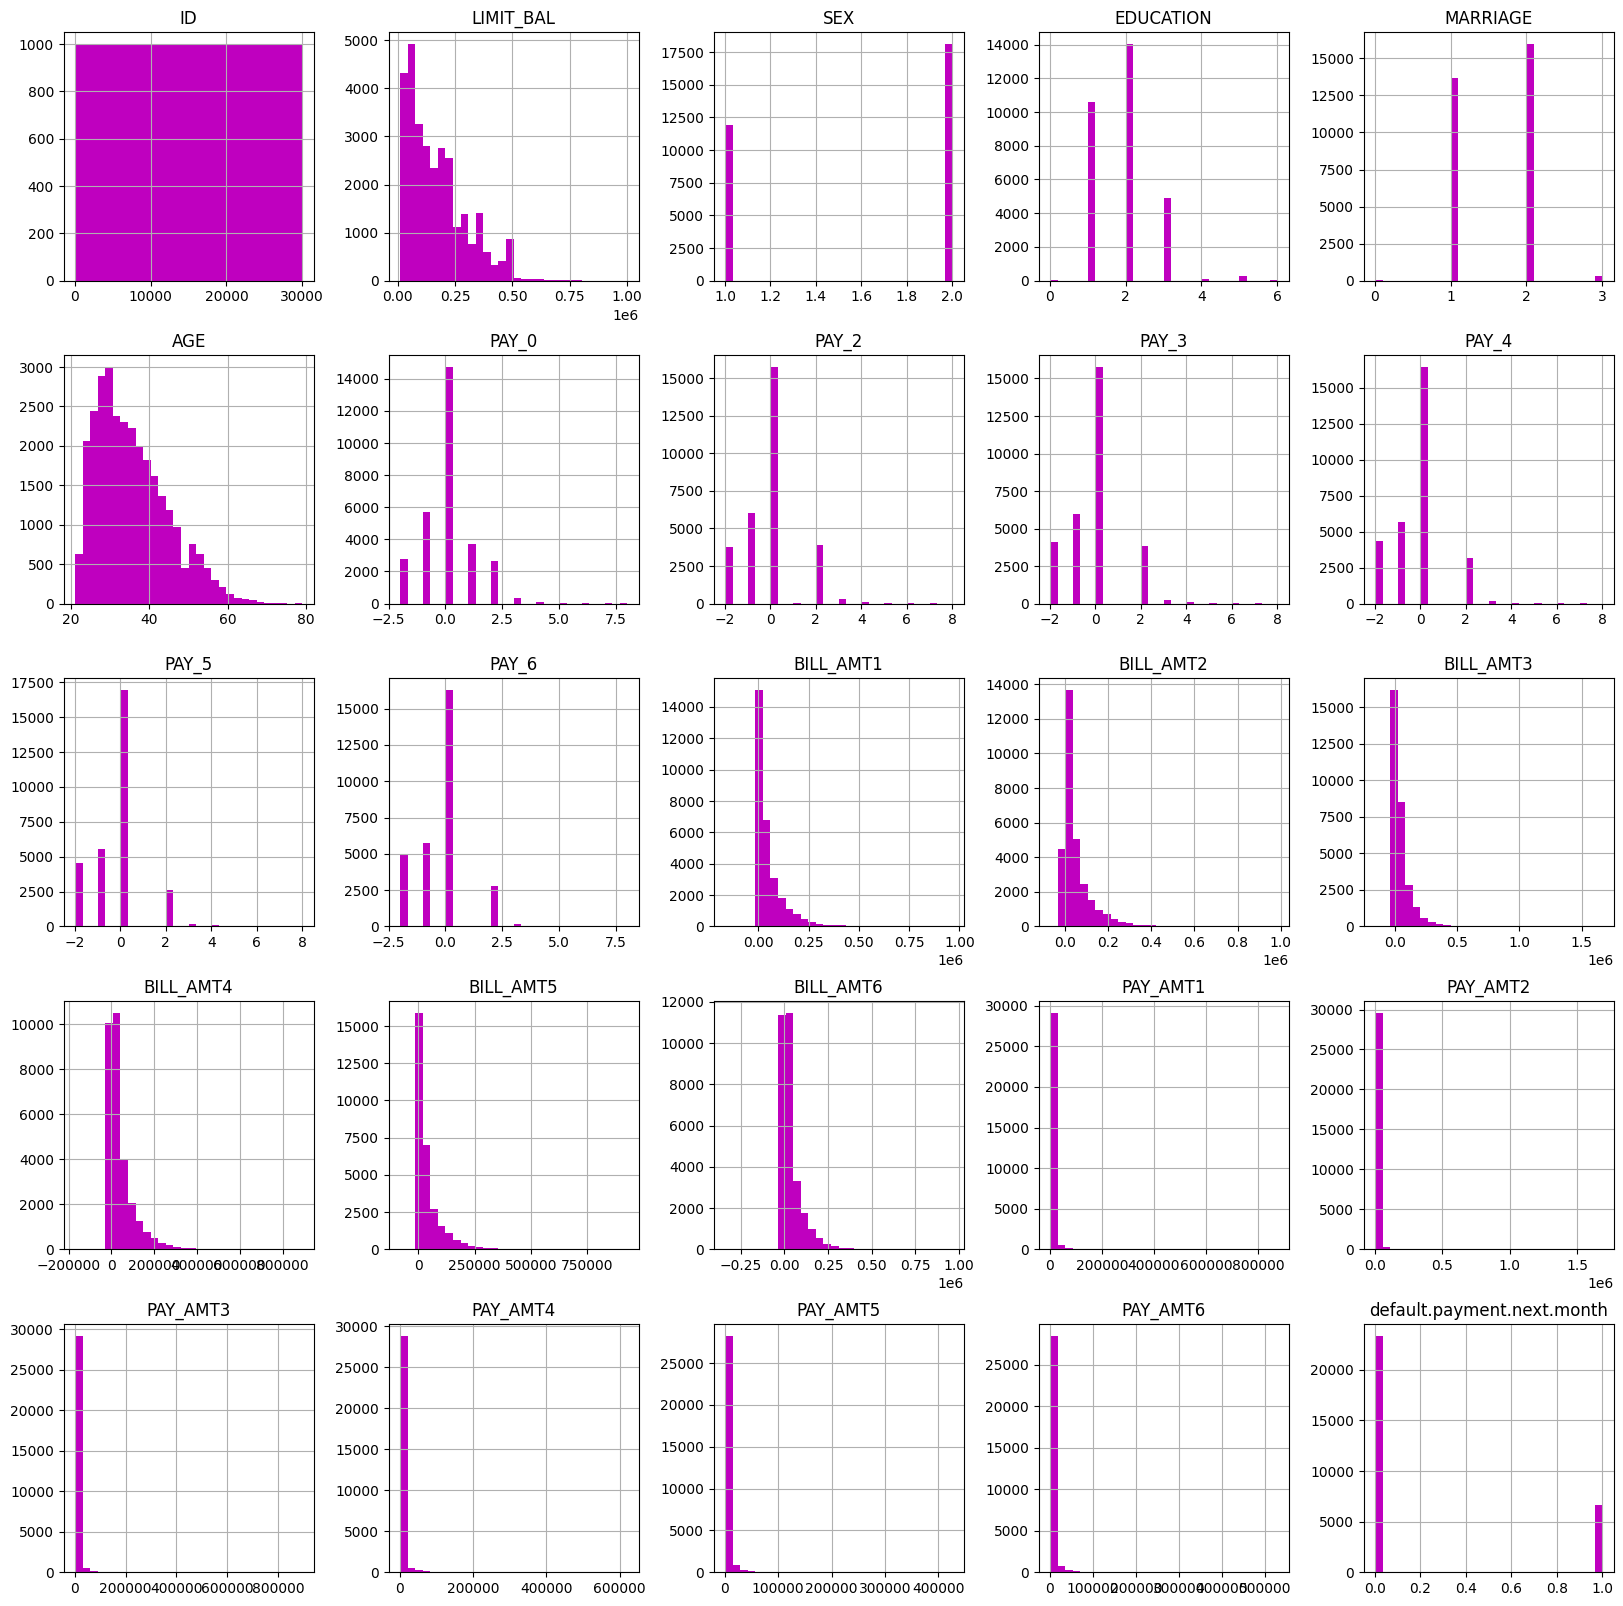

In [ ]:
creditcard_df.hist(bins=30, figsize=(20,20),color='m')

Eliminar la columna ID

In [ ]:
creditcard_df.drop(['ID'], axis=1, inplace=True)


In [ ]:
creditcard_df

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,1,3,1,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,150000.0,1,3,2,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,30000.0,1,2,2,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,80000.0,1,3,1,41,1,-1,0,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


Veamos cuanto clientes podrian incumplir con el pago de tarjetas de credito


In [ ]:
cc_default_df = creditcard_df[creditcard_df['default.payment.next.month'] == 1]
cc_node_default_df = creditcard_df[creditcard_df['default.payment.next.month'] == 0]

Contamos el numero delcientes qye se quedaron y se fueron

In [ ]:
print("Tota", len(creditcard_df))
print("NUmero de clientes que incumplieron sus ágos con tarjetas de crédito= ", len(cc_default_df))
print("Porcentaje de numeros de clientes que incumplieron con suspagos con tarejtas de creditp = ", len(cc_default_df)/len(creditcard_df)*100)
print("NUmero de clientes que cumplieron sus ágos con tarjetas de crédito= ", len(cc_node_default_df))
print("Porcentaje de numeros de clientes que cumplieron con suspagos con tarejtas de creditp = ", len(cc_node_default_df)/len(creditcard_df)*100)

Tota 30000
NUmero de clientes que incumplieron sus ágos con tarjetas de crédito=  6636
Porcentaje de numeros de clientes que incumplieron con suspagos con tarejtas de creditp =  22.12
NUmero de clientes que cumplieron sus ágos con tarjetas de crédito=  23364
Porcentaje de numeros de clientes que cumplieron con suspagos con tarejtas de creditp =  77.88000000000001


In [ ]:
cc_default_df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,6636.000000,6636.000000,6636.000000,6636.000000,6636.000000,6636.000000,6636.000000,6636.000000,6636.000000,6636.000000,...,6636.000000,6636.000000,6636.000000,6636.000000,6636.000000,6636.000000,6636.000000,6636.000000,6636.000000,6636.0
mean,130109.656420,1.567058,1.894665,1.528029,35.725738,0.668174,0.458258,0.362116,0.254521,0.167872,...,42036.950573,39540.190476,38271.435503,3397.044153,3388.649638,3367.351567,3155.626733,3219.139542,3441.482068,1.0
std,115378.540571,0.495520,0.728096,0.525433,9.693438,1.383252,1.502243,1.499401,1.508535,1.482833,...,64351.076092,61424.695949,59579.674268,9544.252427,11737.986064,12959.624486,11191.973162,11944.731175,13464.005894,0.0
min,10000.000000,1.000000,1.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-65167.000000,-53007.000000,-339603.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,...,2141.500000,1502.750000,1150.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
50%,90000.000000,2.000000,2.000000,2.000000,34.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,19119.500000,18478.500000,18028.500000,1636.000000,1533.500000,1222.000000,1000.000000,1000.000000,1000.000000,1.0
75%,200000.000000,2.000000,2.000000,2.000000,42.000000,2.000000,2.000000,2.000000,2.000000,0.000000,...,50175.750000,47853.000000,47424.000000,3478.250000,3309.750000,3000.000000,2939.250000,3000.000000,2974.500000,1.0
max,740000.000000,2.000000,6.000000,3.000000,75.000000,8.000000,7.000000,8.000000,8.000000,8.000000,...,548020.000000,547880.000000,514975.000000,300000.000000,358689.000000,508229.000000,432130.000000,332000.000000,345293.000000,1.0


In [ ]:
cc_node_default_df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,23364.000000,23364.000000,23364.000000,23364.000000,23364.000000,23364.000000,23364.000000,23364.000000,23364.000000,23364.000000,...,23364.000000,23364.000000,23364.000000,23364.000000,2.336400e+04,23364.000000,23364.000000,23364.000000,23364.000000,23364.0
mean,178099.726074,1.614150,1.841337,1.558637,35.417266,-0.211222,-0.301917,-0.316256,-0.355633,-0.389488,...,43611.165254,40530.445343,39042.268704,6307.337357,6.640465e+03,5753.496833,5300.529319,5248.220296,5719.371769,0.0
std,131628.359660,0.486806,0.806780,0.520794,9.077355,0.952464,1.035191,1.048378,1.013162,0.977591,...,64324.796730,60617.268112,59547.015717,18014.508990,2.530226e+04,18684.255937,16689.778060,16071.667860,18792.950473,0.0
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-209051.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0
25%,70000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2360.000000,1823.000000,1265.500000,1163.750000,1.005000e+03,600.000000,390.000000,369.000000,300.000000,0.0
50%,150000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19000.000000,17998.000000,16679.000000,2459.500000,2.247500e+03,2000.000000,1734.000000,1765.000000,1706.000000,0.0
75%,250000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,55988.000000,51135.250000,49842.500000,5606.250000,5.311250e+03,5000.000000,4602.000000,4600.000000,4545.000000,0.0
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,7.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.000000,621000.000000,426529.000000,528666.000000,0.0


El usuario quiere graficar la matriz de correlación que acaba de calcular.



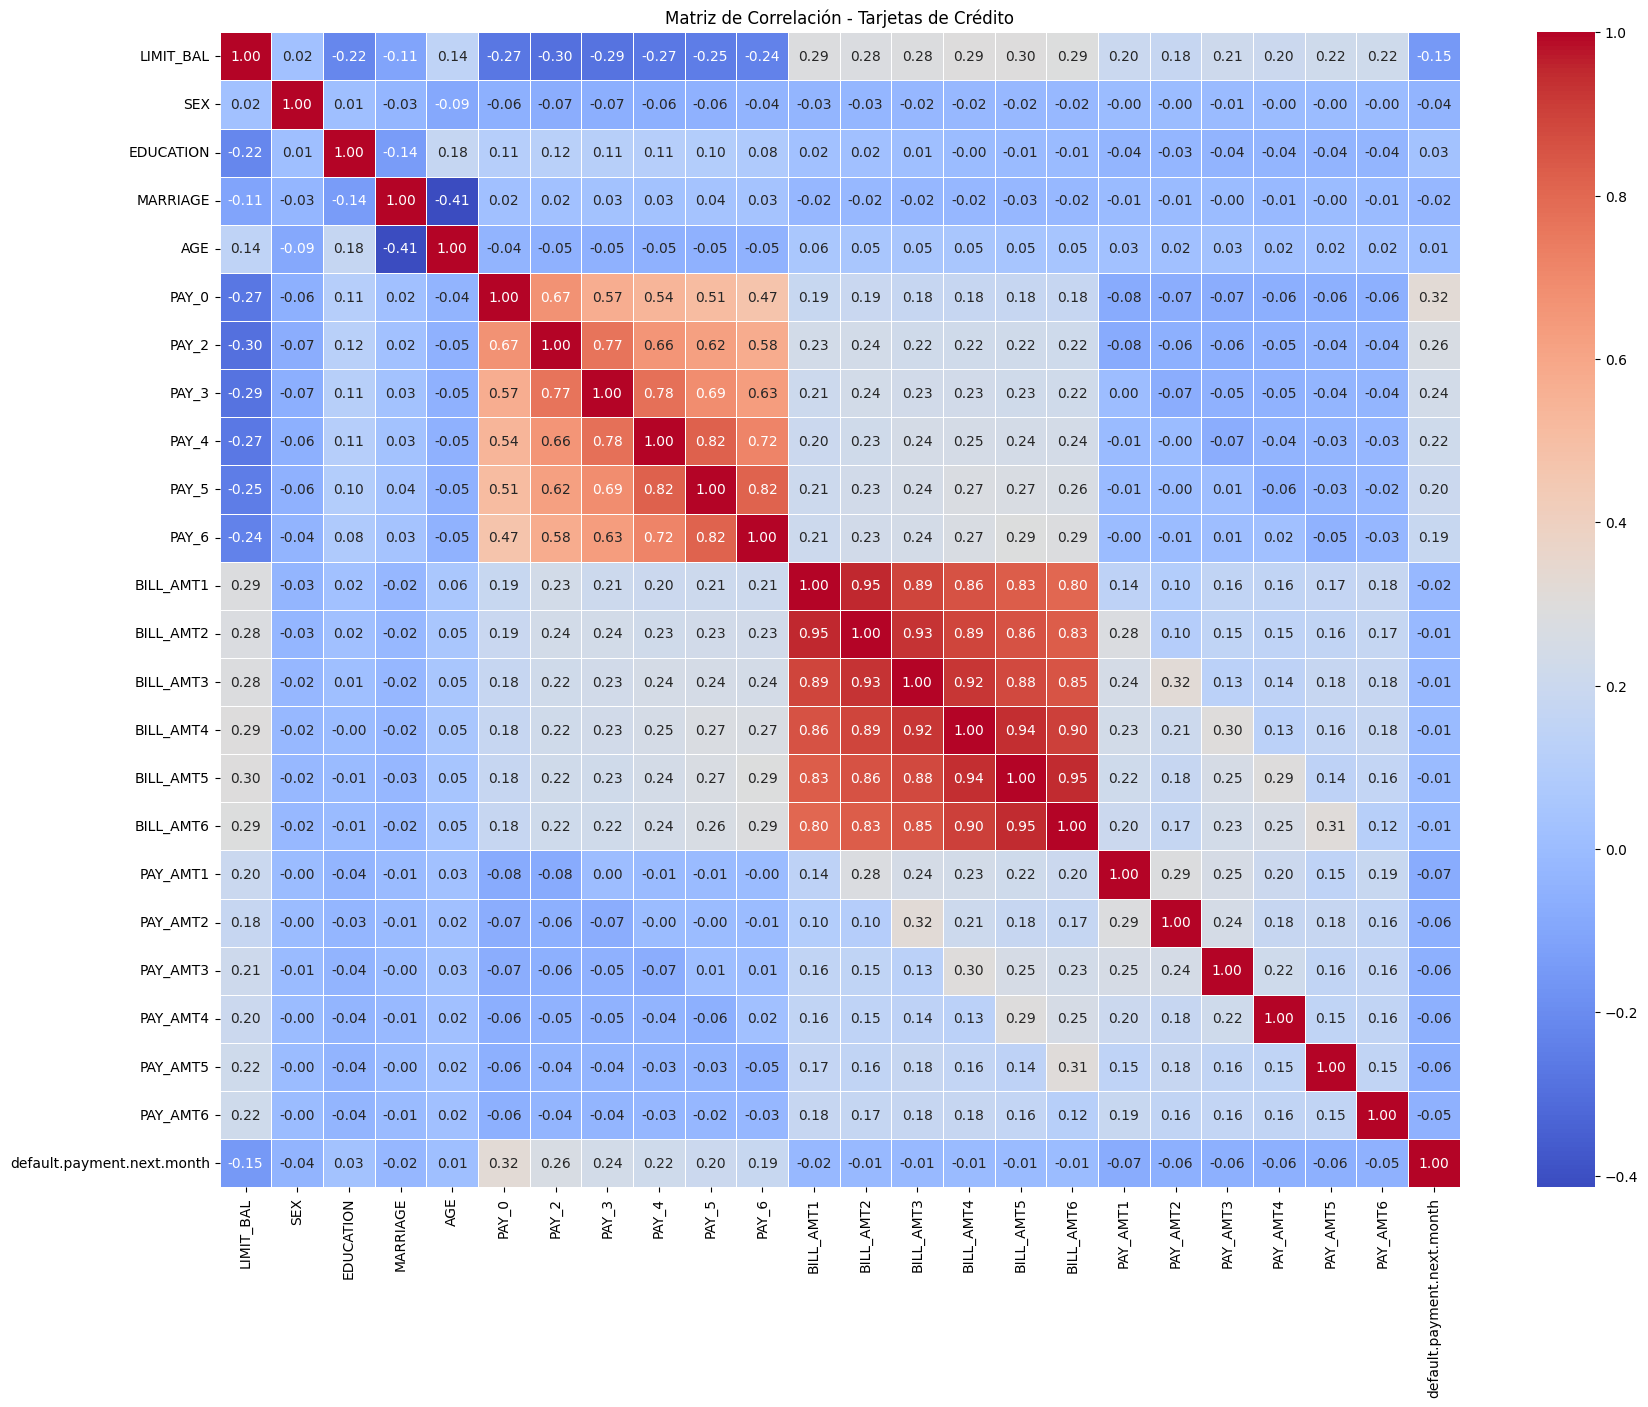

In [ ]:
plt.figure(figsize=(20, 15))
sns.heatmap(creditcard_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación - Tarjetas de Crédito')
plt.show()


In [ ]:
creditcard_df.corr()


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
LIMIT_BAL,1.000000,0.024755,-0.219161,-0.108139,0.144713,-0.271214,-0.296382,-0.286123,-0.267460,-0.249411,...,0.293988,0.295562,0.290389,0.195236,0.178408,0.210167,0.203242,0.217202,0.219595,-0.153520
SEX,0.024755,1.000000,0.014232,-0.031389,-0.090874,-0.057643,-0.070771,-0.066096,-0.060173,-0.055064,...,-0.021880,-0.017005,-0.016733,-0.000242,-0.001391,-0.008597,-0.002229,-0.001667,-0.002766,-0.039961
EDUCATION,-0.219161,0.014232,1.000000,-0.143464,0.175061,0.105364,0.121566,0.114025,0.108793,0.097520,...,-0.000451,-0.007567,-0.009099,-0.037456,-0.030038,-0.039943,-0.038218,-0.040358,-0.037200,0.028006
MARRIAGE,-0.108139,-0.031389,-0.143464,1.000000,-0.414170,0.019917,0.024199,0.032688,0.033122,0.035629,...,-0.023344,-0.025393,-0.021207,-0.005979,-0.008093,-0.003541,-0.012659,-0.001205,-0.006641,-0.024339
AGE,0.144713,-0.090874,0.175061,-0.414170,1.000000,-0.039447,-0.050148,-0.053048,-0.049722,-0.053826,...,0.051353,0.049345,0.047613,0.026147,0.021785,0.029247,0.021379,0.022850,0.019478,0.013890
PAY_0,-0.271214,-0.057643,0.105364,0.019917,-0.039447,1.000000,0.672164,0.574245,0.538841,0.509426,...,0.179125,0.180635,0.176980,-0.079269,-0.070101,-0.070561,-0.064005,-0.058190,-0.058673,0.324794
PAY_2,-0.296382,-0.070771,0.121566,0.024199,-0.050148,0.672164,1.000000,0.766552,0.662067,0.622780,...,0.222237,0.221348,0.219403,-0.080701,-0.058990,-0.055901,-0.046858,-0.037093,-0.036500,0.263551
PAY_3,-0.286123,-0.066096,0.114025,0.032688,-0.053048,0.574245,0.766552,1.000000,0.777359,0.686775,...,0.227202,0.225145,0.222327,0.001295,-0.066793,-0.053311,-0.046067,-0.035863,-0.035861,0.235253
PAY_4,-0.267460,-0.060173,0.108793,0.033122,-0.049722,0.538841,0.662067,0.777359,1.000000,0.819835,...,0.245917,0.242902,0.239154,-0.009362,-0.001944,-0.069235,-0.043461,-0.033590,-0.026565,0.216614
PAY_5,-0.249411,-0.055064,0.097520,0.035629,-0.053826,0.509426,0.622780,0.686775,0.819835,1.000000,...,0.271915,0.269783,0.262509,-0.006089,-0.003191,0.009062,-0.058299,-0.033337,-0.023027,0.204149


In [ ]:
role = 'arn:aws:iam::231351515337:role/Rol-Entrenamiento-SageMaker'
prefix = 'sagemaker/tarjetas-credito-xgboost'

print(f"El rol de ejecución es: {role}")

El rol de ejecución es: arn:aws:iam::231351515337:role/Rol-Entrenamiento-SageMaker


In [ ]:
from sklearn.model_selection import train_test_split
import os

# 1. Mover la variable objetivo a la primera columna
target_col = 'default.payment.next.month'
cols = [target_col] + [col for col in creditcard_df.columns if col != target_col]
df_sagemaker = creditcard_df[cols]

# 2. Dividir los datos (Train: 70%, Validation: 20%, Test: 10%)
train_data, temp_data = train_test_split(df_sagemaker, test_size=0.3, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.33, random_state=42)

# Separar X para hacer el entrenamiento local
y_train = train_data.iloc[:, 0]
X_train = train_data.iloc[:, 1:]

y_val = val_data.iloc[:, 0]
X_val = val_data.iloc[:, 1:]

# 3. Guardar localmente SIN encabezados ni índice como lo es Requisito de XGBoost
train_data.to_csv('train.csv', index=False, header=False)
val_data.to_csv('validation.csv', index=False, header=False)
# Guardamos el test sin la variable objetivo para hacer predicciones después
test_data.drop(columns=[target_col]).to_csv('test.csv', index=False, header=False)

# 4. Subir los archivos a S3 usando la sesión de Boto3 autenticada
print("Subiendo train.csv a S3...")
boto_session.resource('s3').Bucket(bucket).Object(os.path.join(prefix, 'train/train.csv')).upload_file('train.csv')

print("Subiendo validation.csv a S3...")
boto_session.resource('s3').Bucket(bucket).Object(os.path.join(prefix, 'validation/validation.csv')).upload_file('validation.csv')

# 5. Crear los "canales" de entrada para que SageMaker sepa de dónde leer
s3_input_train = sagemaker.inputs.TrainingInput(s3_data=f's3://{bucket}/{prefix}/train', content_type='csv')
s3_input_validation = sagemaker.inputs.TrainingInput(s3_data=f's3://{bucket}/{prefix}/validation', content_type='csv')

print("¡Datos adecuadamente formateados, variables creadas y subidos a S3 exitosamente!")

Subiendo train.csv a S3...
Subiendo validation.csv a S3...
¡Datos adecuadamente formateados, variables creadas y subidos a S3 exitosamente!


In [ ]:
import xgboost as xgb
import tarfile
import os

print(f"Usando XGBoost versión: {xgb.__version__}")

# 1. ENTRENAMIENTO LOCAL
modelo_final = xgb.XGBClassifier(
    max_depth=5,
    learning_rate=0.2,
    gamma=4,
    min_child_weight=6,
    subsample=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    n_estimators=100,
    use_label_encoder=False
)

print("Entrenando el modelo en Colab...")
# Convertimos los DataFrames a arreglos de NumPy con values
modelo_final.fit(
    X_train.values,
    y_train.values,
    eval_set=[(X_val.values, y_val.values)],
    verbose=False
)
print("¡Entrenamiento completado!")

# 2. EMPAQUETADO PARA AWS
nombre_modelo_aws = 'xgboost-model' # Sin json com lo pide AWS
modelo_final.save_model(nombre_modelo_aws)

print("Empaquetando en model.tar.gz...")
with tarfile.open('model.tar.gz', 'w:gz') as tar:
    tar.add(nombre_modelo_aws)

# 3. SUBIDA A S3
llave_s3_modelo = os.path.join(prefix, 'output/model.tar.gz')
ruta_completa_s3 = f"s3://{bucket}/{llave_s3_modelo}"

print(f"Subiendo a AWS S3 ({bucket})...")
boto_session.resource('s3').Bucket(bucket).Object(llave_s3_modelo).upload_file('model.tar.gz')

print("--------------------------------------------------")
print(f"¡Éxito! Modelo alojado en: {ruta_completa_s3}")

Usando XGBoost versión: 1.5.1
Entrenando el modelo en Colab...
¡Entrenamiento completado!
Empaquetando en model.tar.gz...
Subiendo a AWS S3 (sagemaker-us-east-1-231351515337)...
--------------------------------------------------
¡Éxito! Modelo alojado en: s3://sagemaker-us-east-1-231351515337/sagemaker/tarjetas-credito-xgboost/output/model.tar.gz


In [ ]:
from sagemaker.image_uris import retrieve
import sagemaker

# 1. Recuperamos el contenedor oficial de AWS para la versión 1.5-1 (la misma con la que entrenamos)
container = retrieve('xgboost', aws_region, '1.5-1')

print("Configurando el modelo con paridad de versiones en SageMaker...")
xgb_model_aws = sagemaker.model.Model(
    image_uri=container,
    model_data=ruta_completa_s3, # La ruta del S3 que acabamos de crear
    role=role,
    sagemaker_session=sagemaker_session
)

print("Desplegando el Endpoint (API)... AWS tardará unos 5 a 10 minutos.")
print("Verás muchos guiones (---). ¡Ve por un café y no cierres la pestaña!")

# 2. Encendemos el servidor de inferencia (API)
predictor = xgb_model_aws.deploy(
    initial_instance_count=1,
    instance_type='ml.t2.medium' # Servidor económico para inferencia
)

print("\n--------------------------------------------------")
print(f"¡Endpoint creado exitosamente! Tu modelo ya es un servicio web.")
print(f"Nombre de tu API: {predictor.endpoint_name}")

Configurando el modelo con paridad de versiones en SageMaker...
Desplegando el Endpoint (API)... AWS tardará unos 5 a 10 minutos.
Verás muchos guiones (---). ¡Ve por un café y no cierres la pestaña!
-----------!
--------------------------------------------------
¡Endpoint creado exitosamente! Tu modelo ya es un servicio web.


AttributeError: 'NoneType' object has no attribute 'endpoint_name'

## Prueba de la API

In [ ]:
from sagemaker.predictor import Predictor
from sagemaker.serializers import CSVSerializer

# 1. Recuperamos el nombre del endpoint
nombre_endpoint = xgb_model_aws.endpoint_name
print(f"¡El servidor está vivo! Conectando a la API: {nombre_endpoint}")

# 2. Creamos el conector manualmente
predictor = Predictor(
    endpoint_name=nombre_endpoint,
    sagemaker_session=sagemaker_session,
    serializer=CSVSerializer()
)

print("--------------------------------------------------")
print("Preparando datos de prueba del cliente #1 (SIN la variable objetivo)...")

# 3. LA CORRECCIÓN: Usamos iloc[:, 1:] para saltarnos la primera columna
cliente_prueba = test_data.iloc[0:1, 1:].to_csv(header=False, index=False).strip()
print(f"Datos enviados a AWS (Solo características): \n{cliente_prueba}")

# 4. ¡HACEMOS LA PREDICCIÓN A LA NUBE!
print("Enviando petición a AWS...")
respuesta = predictor.predict(cliente_prueba)

# Convertimos la respuesta binaria a un número decimal
probabilidad = float(respuesta.decode('utf-8'))

print("\n--------------------------------------------------")
print(f"¡RESPUESTA DE AWS RECIBIDA!")
print(f"Probabilidad de incumplimiento de pago: {probabilidad * 100:.2f}%")

if probabilidad > 0.5:
    print("Decisión del Modelo: RECHAZAR CRÉDITO (Alto riesgo de impago)")
else:
    print("Decisión del Modelo: APROBAR CRÉDITO (Bajo riesgo de impago)")

¡El servidor está vivo! Conectando a la API: sagemaker-xgboost-2026-03-20-03-05-19-642
--------------------------------------------------
Preparando datos de prueba del cliente #1 (SIN la variable objetivo)...
Datos enviados a AWS (Solo características): 
25136,250000.0,1,3,1,56,-1,-1,-1,-1,-1,-1,6297.0,8636.0,17038.0,5169.0,12818.0,2328.0,8657.0,23744.0,5169.0,14008.0,2328.0,17285.0
Enviando petición a AWS...

--------------------------------------------------
¡RESPUESTA DE AWS RECIBIDA!
Probabilidad de incumplimiento de pago: 2.21%
🤖 Decisión del Modelo: APROBAR CRÉDITO (Bajo riesgo de impago)
